In [92]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Download latest version
path = kagglehub.dataset_download("yasserh/nyc-taxi-trip-duration")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nyc-taxi-trip-duration' dataset.
Path to dataset files: /kaggle/input/nyc-taxi-trip-duration


In [93]:
df = pd.read_csv(f"{path}/NYC.csv")
df.to_csv("train.csv")

In [94]:
df.head(10)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443
6,id1813257,1,2016-06-17 22:34:59,2016-06-17 22:40:40,4,-73.969017,40.757839,-73.957405,40.765896,N,341
7,id1324603,2,2016-05-21 07:54:58,2016-05-21 08:20:49,1,-73.969276,40.797779,-73.922470,40.760559,N,1551
8,id1301050,1,2016-05-27 23:12:23,2016-05-27 23:16:38,1,-73.999481,40.738400,-73.985786,40.732815,N,255
9,id0012891,2,2016-03-10 21:45:01,2016-03-10 22:05:26,1,-73.981049,40.744339,-73.973000,40.789989,N,1225


In [95]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

Target variable is trip_duration

In [96]:
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


In [97]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

In [98]:
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_weekday'] = df['pickup_datetime'].dt.weekday
df['pickup_month'] = df['pickup_datetime'].dt.month

In [99]:
df.head(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_weekday,pickup_month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,0,3
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1


## Description
this function converts the raw long lat degrees into radians as math can understand RADIANS, it uses the earth's radius to calculate the surface distances b/w two point in km and uses some trigo 

In [100]:
def haversine(lat1, lon1, lat2, lon2):
  R = 6371 #km
  lat1,lon1,lat2,lon2 = map(np.radians,[lat1,lon1,lat2,lon2])
  dlat = lat2 - lat1
  dlon = lon2 - lon1

  a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
  c = 2* np.arcsin(np.sqrt(a))
  return R * c

In [101]:
df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

In [102]:
df.head(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_weekday,pickup_month,distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,0,3,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1,6.385098


In [103]:
df.shape

(1458644, 16)

In [104]:
print(df['trip_duration'].describe())

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64


In [105]:
df = df[(df['trip_duration'] >=60) & (df['trip_duration']<=7200)]

In [106]:
df['trip_duration'].describe()

,trip_duration
count,1.447796e+06
mean,8.408756e+02
std,6.532622e+02
min,6.000000e+01
25%,4.010000e+02
50%,6.650000e+02
75%,1.076000e+03
max,7.191000e+03


In [107]:
df['distance_km'].describe()

,distance_km
count,1.447796e+06
mean,3.457906e+00
std,4.290748e+00
min,0.000000e+00
25%,1.244395e+00
50%,2.106275e+00
75%,3.892099e+00
max,1.240909e+03


In [108]:
df = df[(df['distance_km'] >=1) & (df['distance_km']<=100)]

In [109]:
df['distance_km'].describe()

,distance_km
count,1.210745e+06
mean,3.992273e+00
std,4.099297e+00
min,1.000001e+00
25%,1.625184e+00
50%,2.506773e+00
75%,4.482433e+00
max,9.758621e+01


In [110]:
df[['distance_km','trip_duration']].corr()

,distance_km,trip_duration
distance_km,1.000000,0.755058
trip_duration,0.755058,1.000000


## Model Preparation

In [ ]:
X = df.drop(columns=[
    'trip_duration',
    'id',
    'dropoff_datetime',
    'pickup_datetime'
])
y = df['trip_duration']

In [112]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [113]:
X_train = pd.get_dummies(X_train,drop_first=True)
X_test = pd.get_dummies(X_test,drop_first=True)

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [114]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [115]:
from sklearn.metrics import mean_absolute_error, r2_score

preds = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 208.05319213867188
R2: 0.7755590677261353


In [116]:
feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feat_imp.head(10))

distance_km          0.817988
pickup_hour          0.048497
pickup_weekday       0.034821
pickup_month         0.023515
dropoff_latitude     0.018387
pickup_longitude     0.013356
dropoff_longitude    0.011442
pickup_latitude      0.009784
vendor_id            0.009570
pickup_day           0.008228
dtype: float32


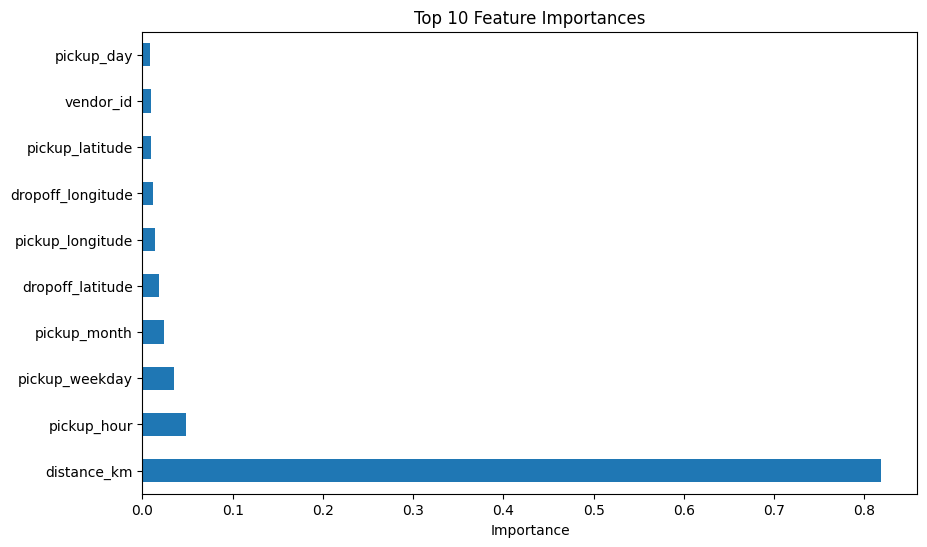

In [117]:
plt.figure(figsize=(10,6))

feat_imp.head(10).plot(
    kind='barh'
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

## CVs

In [118]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring = 'r2'
)
print('CV scores', scores)
print("mean cv scores", scores.mean())

CV scores [0.77915835 0.77244437 0.77579939 0.77924156 0.77506804]
mean cv scores 0.7763423442840576


In [119]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb_tune = XGBRegressor(
    random_state=42,
    tree_method='hist'
)

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [120]:

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=params,
    n_iter=10,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [4, 6, 8],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [121]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
0.7923328081766764


In [122]:
best_xgb = random_search.best_estimator_

preds = best_xgb.predict(X_test)

print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R2: 0.7914965748786926
MAE: 199.02435302734375


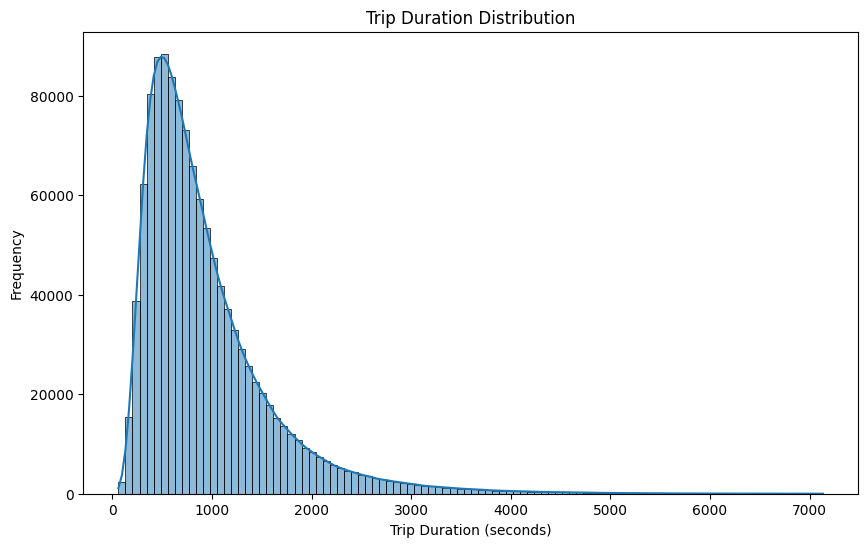

In [123]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['trip_duration'],
    bins=100,
    kde=True
)

plt.title("Trip Duration Distribution")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

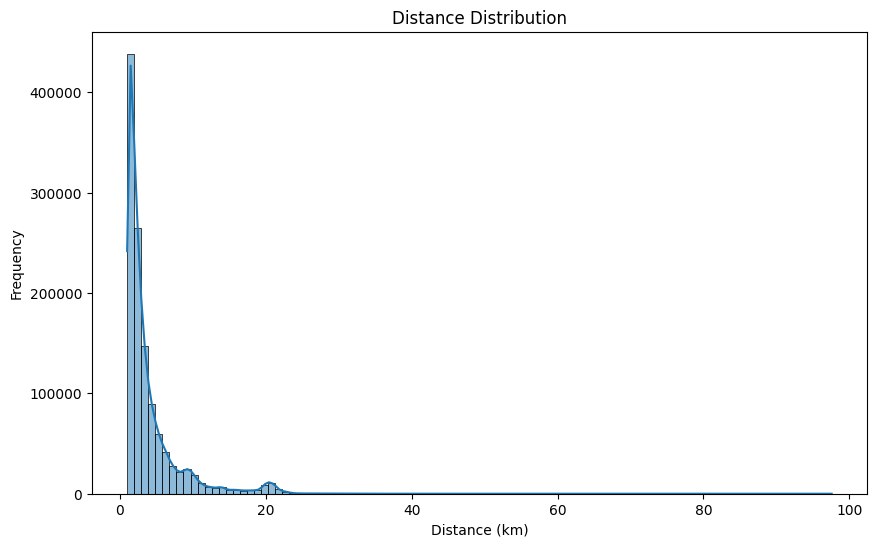

In [124]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['distance_km'],
    bins=100,
    kde=True
)

plt.title("Distance Distribution")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")

plt.show()

## Residuals (ERROR ANALYSIS)

In [128]:
results = X_test.copy()

results['actual'] = y_test
results['predicted'] = preds
results['error'] = results['actual'] - results['predicted']
results['abs_error'] = abs(results['error'])

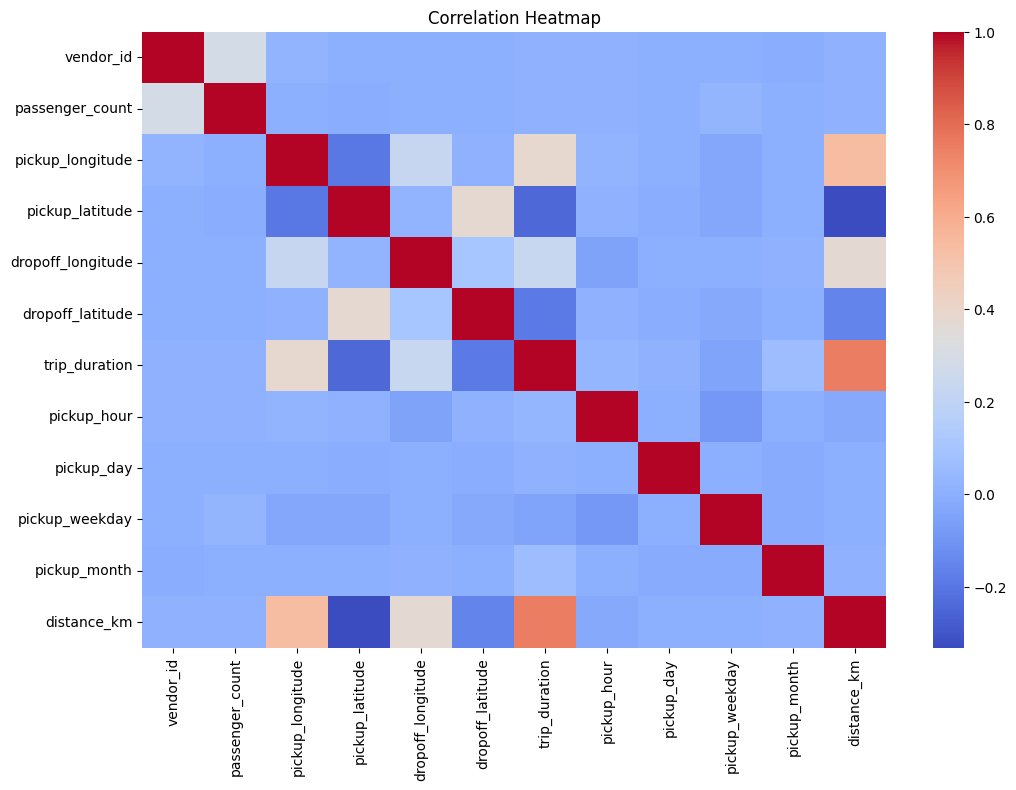

In [125]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

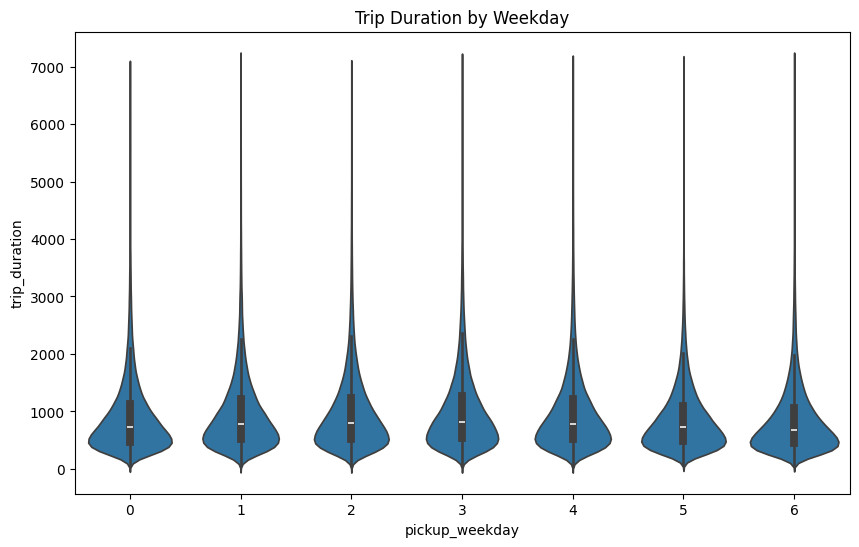

In [126]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='pickup_weekday',
    y='trip_duration',
    data=df
)

plt.title("Trip Duration by Weekday")

plt.show()

In [129]:
results.sort_values(
    by='abs_error',
    ascending=False
).head(10)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_hour,pickup_day,pickup_weekday,pickup_month,distance_km,store_and_fwd_flag_Y,actual,predicted,error,abs_error
1025043,2,1,-73.989151,40.730480,-74.052544,40.735569,0,6,0,6,5.371281,False,6978,1248.438599,5729.561401,5729.561401
886081,1,1,-74.003128,40.734951,-73.984741,40.728767,19,30,2,3,1.695008,True,6367,655.526306,5711.473694,5711.473694
315767,1,1,-73.997696,40.736298,-73.986443,40.755070,11,14,1,6,2.292559,False,6866,1167.290161,5698.709839,5698.709839
315330,2,6,-74.005493,40.718037,-74.001854,40.730179,22,28,3,1,1.384541,False,6120,436.936340,5683.063660,5683.063660
989465,1,2,-74.012711,40.702042,-73.986366,40.673351,0,29,6,5,3.887347,True,6514,926.362610,5587.637390,5587.637390
217992,1,2,-73.962128,40.757793,-73.996002,40.735386,14,14,1,6,3.788323,False,6914,1447.484619,5466.515381,5466.515381
101074,2,2,-73.989662,40.729706,-73.946808,40.776321,1,13,6,3,6.316508,False,6261,1109.680786,5151.319214,5151.319214
836229,1,1,-73.988655,40.744389,-74.001862,40.722797,20,20,2,4,2.646169,False,5830,797.242920,5032.757080,5032.757080
1185801,2,6,-73.967094,40.766434,-73.979645,40.754616,7,9,3,6,1.686470,False,5687,658.846069,5028.153931,5028.153931
420316,1,1,-73.992256,40.748795,-73.989334,40.758633,15,16,2,3,1.121295,False,5677,659.890625,5017.109375,5017.109375


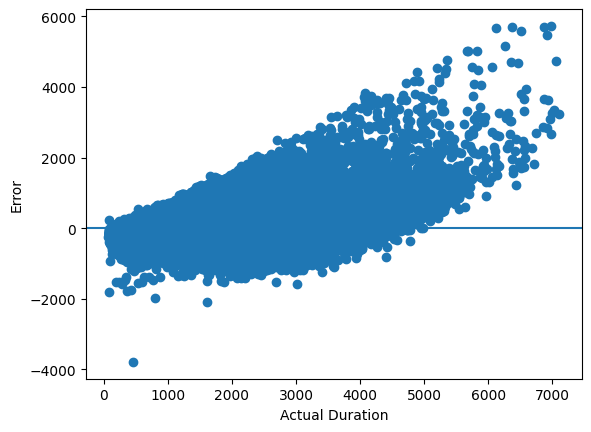

In [130]:
plt.scatter(results['actual'], results['error'])
plt.axhline(y=0)
plt.xlabel("Actual Duration")
plt.ylabel("Error")
plt.show()

In [ ]:
long_trips = results[results['actual'] > 3000]
print(long_trips['abs_error'].mean())

In [131]:
df_clean = df.to_csv("train_cleaned.csv")

# Project model finished now only deployment and app

In [132]:
import joblib

joblib.dump(best_xgb, "taxi_model.pkl")

['taxi_model.pkl']

In [133]:
joblib.dump(
    X_train.columns.tolist(),
"model_columns.pkl"
)

['model_columns.pkl']